# How the trail camera decides to take a photograph

This notebook takes apart [`step7_ai_motion_detection.py`](../step7_ai_motion_detection.py),
the program running on the wildlife cameras, and shows each step working on real
pictures the cameras actually took.

Every image here came off `wildlifecam4` on 23 August 2026, pointed at a patio
with a handful of cheerios on the ground to attract a bird. Nothing is staged and
nothing is simulated except where it says so.

The camera has one job: **decide whether this frame is worth keeping.** It does
not try to say what the animal is — a laptop does that later with much bigger
models. So everything below is in service of one question, asked four times a
second: *did something just move?*

The rules, in the order the program applies them:

| | rule | outcome |
|---|---|---|
| 1 | too dark to see anything | skip |
| 2 | the light changed | skip |
| 3 | the whole treeline is moving | skip |
| 4 | too small, or the wrong shape | skip |
| 5 | a big blob | **SAVE** |
| 6 | a small blob, seen twice | **SAVE** |
| 7 | a small blob the AI agrees on | **SAVE** |
| 8 | anything else | wait and see |

We will build up to that checklist one piece at a time.

## Setup

The thresholds are read straight out of the camera program rather than copied
here, so this notebook cannot quietly disagree with the code that is actually
running.

In [1]:
import json, re
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("data")
STEP7 = Path("..") / "step7_ai_motion_detection.py"

# Read the constants out of step7 itself.  Everything above the argument
# parsing is plain assignments, so it can simply be executed.
source = STEP7.read_text().split("# Command line")[0]
source = "\n".join(l for l in source.splitlines()
                   if "picamera2" not in l and not l.startswith("import cv2"))
K = {}
exec(compile(source, str(STEP7), "exec"), K)

print(f"lores frame        {K['LORES_SIZE'][0]}x{K['LORES_SIZE'][1]}")
print(f"blur kernel        {K['BLUR_KERNEL']}")
print(f"open / close       {K['OPEN_SIZE']} / {K['CLOSE_SIZE']}")
print(f"pixel threshold    {K['PIXEL_THRESHOLD']} (floor)")
print(f"min blob           {K['MIN_BLOB_AREA']} px")
print(f"strong blob        {K['STRONG_BLOB_AREA']} px")
print(f"darkness floor     luma {K['MIN_MEAN_LUMA']}")

lores frame        640x480
blur kernel        11
open / close       7 / 15
pixel threshold    25 (floor)
min blob           599 px
strong blob        1320 px
darkness floor     luma 25


In [2]:
plt.rcParams["figure.dpi"] = 68          # keep the committed notebook small
                                         # enough for GitHub to render inline


def show(*panes, height=3.4, cmap="gray"):
    """Draw one or more labelled images side by side."""
    fig, axes = plt.subplots(1, len(panes),
                             figsize=(4.6 * len(panes), height))
    if len(panes) == 1:
        axes = [axes]
    for ax, (img, title) in zip(axes, panes):
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

index = json.loads((DATA / "index.json").read_text())
print(index["_about"])

Hand-picked frames from wildlifecam4, 23 August 2026, for the notebooks in analysis/.  Real camera output, nothing staged.  No identifiable people: the only person in the set is a foot in a sandal.  Each demonstration pairs a test frame with background frames from the training burst immediately before it, so the light matches -- comparing against a background learned minutes earlier makes the whole scene look like it moved.


## 1. What the camera sees

The sensor is a Raspberry Pi AI Camera (Sony IMX500), 12 megapixels. We ask it
for two pictures of every frame at once:

- **`main`** — 2028×1520 in colour. This is the photograph we keep.
- **`lores`** — a small copy the camera's own hardware produces for free.

The motion rules only ever look at the small one. That is the single most
important thing to understand about the program: all the decisions below are
made on an image smaller than a postage stamp.

main stream : 2028x1520 colour = 9,247,680 numbers per frame
lores stream: 640x480 = 921,600 numbers (10x fewer)


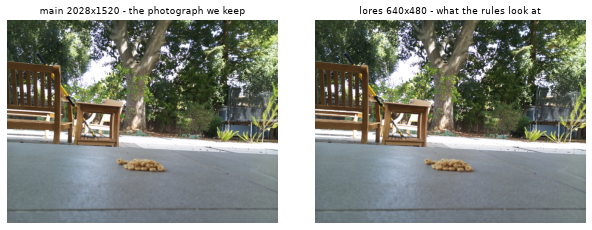

In [3]:
full = cv2.imread(str(DATA / "scene_cheerios.jpg"))
print(f"main stream : {full.shape[1]}x{full.shape[0]} colour "
      f"= {full.size:,} numbers per frame")

W, H = K["LORES_SIZE"]
lores_colour = cv2.resize(full, (W, H))
print(f"lores stream: {W}x{H} = {lores_colour.size:,} numbers "
      f"({full.size / lores_colour.size:.0f}x fewer)")

show((full, "main 2028x1520 - the photograph we keep"),
     (lores_colour, f"lores {W}x{H} - what the rules look at"))

### Why so small?

It is tempting to think a bigger picture must detect better. It does not, and
this is worth being precise about, because it decides how far the camera can see.

Suppose a fern at the edge of the frame covers 95 pixels and a person walking
past covers 8,960. Double the resolution and **both numbers quadruple** — the
fern becomes 380, the person 35,840. The ratio between them never changes. So
resolution does not help you tell an animal from a weed.

What it does change is the *small* end. The cleanup step later on uses a
fixed-size kernel that erases anything only a few pixels across, whatever it is:

| lores width | deer at 30 m | squirrel at 10 m |
|---|---|---|
| 320 | 14×9 px | 7×4 px — marginal |
| 640 | 28×18 px | 14×8 px |

So the lores size is a **distance setting**. A camera on a patio can use 320×240;
one looking down a long trail wants 640×480, which is what these cameras now
run.

## 2. Brightness, and the night filter

The very first question is whether there is enough light to see anything at all.
After dark this camera has no infra-red lamp, so it turns its gain right up and
photographs its own noise — a black rectangle with sparkles in it. Nothing can
be recognised in that, by us or by a computer.

So the program takes the **mean brightness** of the small frame and stops there
if it is too low.

whole YUV420 buffer (720, 640)   Y plane (480, 640)

mean brightness = 115.3
darkness floor  = 25  -> bright enough
  afternoon                        luma  115.3  keeps watching
  dusk (simulated)                 luma   39.9  keeps watching
  night + sensor noise (simulated) luma   14.0  TOO DARK - skips


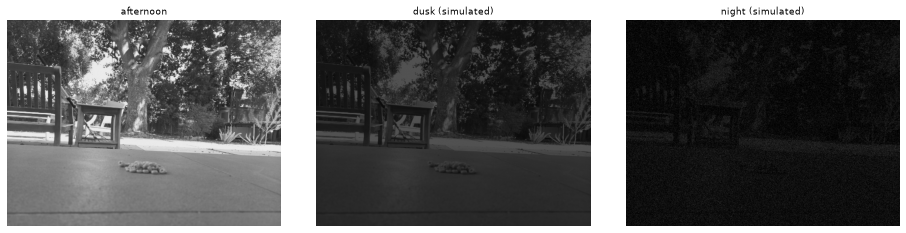

In [4]:
# The lores stream arrives as YUV420: a brightness (Y) plane followed by
# two quarter-size colour planes.  The Y plane IS the greyscale image, so
# the camera gets it for free -- no conversion, no cost.
yuv = cv2.cvtColor(lores_colour, cv2.COLOR_BGR2YUV_I420)
grey_plane = yuv[:H]                      # the Y plane
print(f"whole YUV420 buffer {yuv.shape}   Y plane {grey_plane.shape}")

mean_luma = float(grey_plane.mean())
print(f"\nmean brightness = {mean_luma:.1f}")
print(f"darkness floor  = {K['MIN_MEAN_LUMA']}  -> "
      f"{'bright enough' if mean_luma >= K['MIN_MEAN_LUMA'] else 'too dark, skip'}")

# We have no genuinely dark frames yet, so dim this one to show the gate firing.
# This is the ONLY simulated image in the notebook.
dusk = (grey_plane * 0.35).astype(np.uint8)
night = (grey_plane * 0.12).astype(np.uint8)
night = np.clip(night + np.random.default_rng(0).normal(0, 12, night.shape),
                0, 255).astype(np.uint8)

for img, label in ((grey_plane, "afternoon"), (dusk, "dusk (simulated)"),
                   (night, "night + sensor noise (simulated)")):
    m = img.mean()
    verdict = "keeps watching" if m >= K["MIN_MEAN_LUMA"] else "TOO DARK - skips"
    print(f"  {label:32} luma {m:6.1f}  {verdict}")

show((grey_plane, "afternoon"), (dusk, "dusk (simulated)"),
     (night, "night (simulated)"))

Training bursts use a **stricter** bar than the motion rules do
(`RECORD_MIN_LUMA`, currently 40, against `MIN_MEAN_LUMA` of 25). The two are
asking different questions: *can we tell motion from noise* is a lower hurdle
than *would this picture be worth looking at later*. There is no point filling
an SD card with black rectangles.

## 3. Blur — throwing away detail on purpose

Before comparing anything we blur the frame. This feels wrong the first time you
meet it: we just spent effort getting a sharp picture and now we are smudging it.

The reason is that the camera sits on the ground and shakes by a fraction of a
pixel — wind, a passing truck, the case settling. On flat concrete that shift
changes nothing. Along a sharp edge like a bench slat it changes a great deal,
because a bright pixel and a dark pixel swap places. Blurring first spreads each
edge over several pixels so a tiny shift no longer produces a large difference.

a one-pixel camera shake produces:
  without blur : 39,634 pixels over threshold
  with a 11x11 blur:    628 pixels over threshold


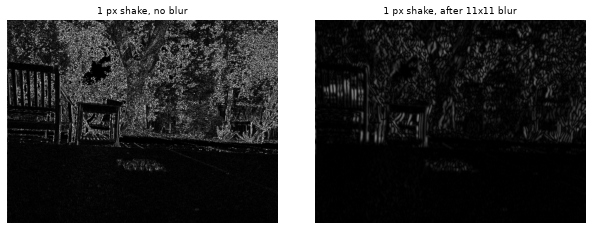

In [5]:
BK = K["BLUR_KERNEL"]
grey = cv2.GaussianBlur(grey_plane, (BK, BK), 0)

# Shift the frame by a single pixel to imitate the camera twitching.
shifted = np.roll(grey_plane, 1, axis=1)
raw_diff = cv2.absdiff(grey_plane, shifted)
blur_diff = cv2.absdiff(grey, cv2.GaussianBlur(shifted, (BK, BK), 0))

print(f"a one-pixel camera shake produces:")
print(f"  without blur : {(raw_diff > 25).sum():6,} pixels over threshold")
print(f"  with a {BK}x{BK} blur: {(blur_diff > 25).sum():6,} pixels over threshold")

show((raw_diff * 4, "1 px shake, no blur"),
     (blur_diff * 4, f"1 px shake, after {BK}x{BK} blur"))

## 4. The background model

A first instinct is to compare each frame with the one before it. That works
until an animal stops moving — a deer pausing to browse vanishes instantly,
and those are exactly the photographs worth having.

So instead the camera keeps a **running average of what the scene usually looks
like** and compares against that. An animal that walks in and stands still stays
visible for as long as it takes the average to forget it.

The average is updated at **two speeds**, and that detail matters more than it
sounds:

learning rate where nothing moves : 0.0250  (forgets over ~10 s)
learning rate under a moving thing: 0.0063  (forgets over ~40 s)



built two backgrounds, one at 15:51 and one at 16:00


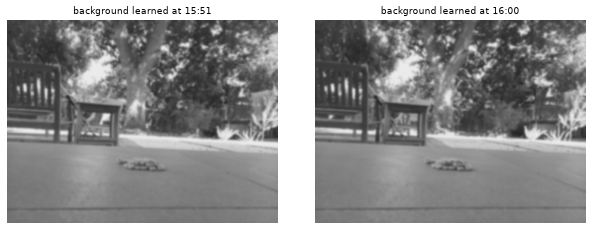

In [6]:
def to_grey(path):
    """Exactly what the camera does: shrink, take the Y plane, blur."""
    img = cv2.imread(str(path))
    small = cv2.resize(img, (W, H))
    plane = cv2.cvtColor(small, cv2.COLOR_BGR2YUV_I420)[:H]
    return cv2.GaussianBlur(plane, (BK, BK), 0)


alpha_quiet = min(1.0, K["LOOP_DELAY"] / K["BACKGROUND_TAU"])
alpha_busy = min(1.0, K["LOOP_DELAY"] / K["BACKGROUND_TAU_BUSY"])
print(f"learning rate where nothing moves : {alpha_quiet:.4f}  "
      f"(forgets over ~{K['BACKGROUND_TAU']:.0f} s)")
print(f"learning rate under a moving thing: {alpha_busy:.4f}  "
      f"(forgets over ~{K['BACKGROUND_TAU_BUSY']:.0f} s)")


def learn(paths):
    """Build the running average the way step7 does, at two speeds."""
    background = to_grey(paths[0]).astype("float32")
    for p in paths[1:]:
        g = to_grey(p)
        cv2.accumulateWeighted(g, background, alpha_busy)    # everywhere, slowly
        cv2.accumulateWeighted(g, background, alpha_quiet)   # again, faster
    return background


# Two backgrounds, each from the training burst just before the frames it is
# compared against.  This matters more than it looks -- see the note below.
bg_motion = learn(sorted(DATA.glob("bg_motion_*.jpg")))
bg_quiet = learn(sorted(DATA.glob("bg_quiet_*.jpg")))
print()
print("built two backgrounds, one at 15:51 and one at 16:00")

show((bg_motion.astype("uint8"), "background learned at 15:51"),
     (bg_quiet.astype("uint8"), "background learned at 16:00"))

**A background is only good for the moment it was learned.** These two are
nine minutes apart and the sun moved between them. Comparing a frame against a
background from minutes earlier makes the entire scene look like it changed —
which is why each demonstration below uses the burst recorded just before it.
The real camera never has this problem, because its background is updated four
times a second, continuously.

### Why two speeds

An earlier version of this program learned the background **only where nothing
was moving**. That sounds sensible and is a trap. A pixel that once looked
different was frozen out of the average for ever, so it stayed different for
ever. Camera shake wrote a permanent scar along every sharp edge in the scene,
the scars grew into one another, and the camera photographed an empty patio
48 times in two minutes.

The fix is that the background now learns *everywhere*, including underneath
whatever is moving — just four times more slowly there. That way a mistake can
never become permanent, while an animal that pauses still takes about
`BACKGROUND_TAU_BUSY` seconds to fade into the scenery.

## 5. Difference, and deciding what counts as changed

Now subtract. Two numbers come out of this step, and they do different jobs.

The **signed** median difference — how the middle pixel of the whole frame
moved, up or down — tells us whether the *light* changed. Grainy noise pushes as
many pixels up as down and cancels to zero; a cloud pushes every pixel the same
way. That one number separates them.

The **unsigned** median tells us how jittery the frame is, and sets the
threshold: on a calm afternoon it stays at 25, on a grainy evening it rises by
itself.

signed median (did the light change?) : -2.0   limit 10
unsigned median (how grainy?)         : 4.0
-> pixel threshold used               : 25


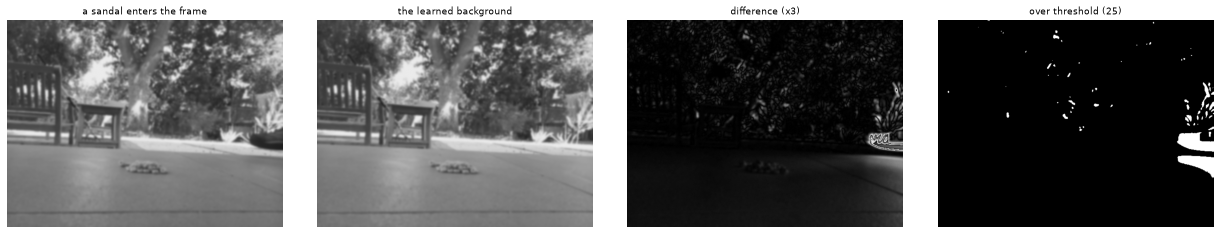

In [7]:
motion = cv2.imread(str(DATA / "motion_sandal.jpg"))
motion_grey = cv2.GaussianBlur(
    cv2.cvtColor(cv2.resize(motion, (W, H)), cv2.COLOR_BGR2YUV_I420)[:H],
    (BK, BK), 0)

bg8 = bg_motion.astype("uint8")
signed = motion_grey.astype(np.int16) - bg8.astype(np.int16)
shift = float(np.median(signed))
noise = float(np.median(np.abs(signed)))

threshold = min(K["MAX_PIXEL_THRESHOLD"],
                max(K["PIXEL_THRESHOLD"],
                    int(K["NOISE_MULTIPLIER"] * noise + 5)))

print(f"signed median (did the light change?) : {shift:+.1f}"
      f"   limit {K['LIGHTING_SHIFT']}")
print(f"unsigned median (how grainy?)         : {noise:.1f}")
print(f"-> pixel threshold used               : {threshold}")

difference = cv2.absdiff(motion_grey, bg8)
_, mask = cv2.threshold(difference, threshold, 255, cv2.THRESH_BINARY)

show((motion_grey, "a sandal enters the frame"), (bg8, "the learned background"),
     (difference * 3, "difference (x3)"), (mask, f"over threshold ({threshold})"))

## 6. Cleaning up: open, then close

The raw mask is speckled. Two morphological steps tidy it, in this order:

- **Open** (erode, then dilate) rubs out lone speckles smaller than the kernel.
- **Close** (dilate, then erode) joins nearby fragments into one shape — an
  animal broken up by a shadow becomes a single blob again.

Closing rather than a plain dilate matters: dilating alone would *inflate* every
blob, so the size thresholds later would mean far less than they say.

  raw            6,721 pixels set
  after open     4,884 pixels set
  after close    5,589 pixels set


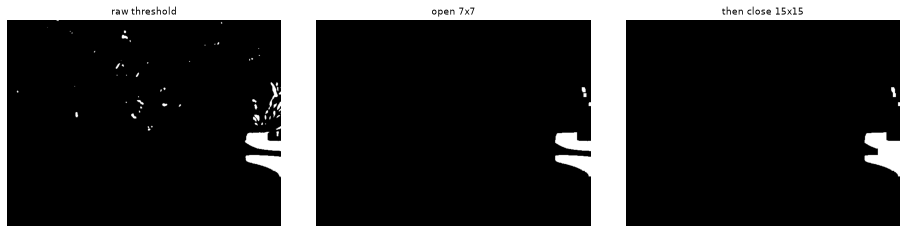

In [8]:
OPEN = cv2.getStructuringElement(cv2.MORPH_RECT, (K["OPEN_SIZE"],) * 2)
CLOSE = cv2.getStructuringElement(cv2.MORPH_RECT, (K["CLOSE_SIZE"],) * 2)

opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, OPEN)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, CLOSE)

for img, label in ((mask, "raw"), (opened, "after open"), (closed, "after close")):
    print(f"  {label:12} {cv2.countNonZero(img):7,} pixels set")

show((mask, "raw threshold"), (opened, f"open {K['OPEN_SIZE']}x{K['OPEN_SIZE']}"),
     (closed, f"then close {K['CLOSE_SIZE']}x{K['CLOSE_SIZE']}"))

## 7. Connected pixels — finding the blob

Counting changed pixels is not enough. Twenty thousand pixels scattered all over
a windy treeline and twenty thousand pixels in one solid lump look identical to
a counter, but only one of them is an animal.

`connectedComponentsWithStats` groups touching pixels into objects and hands back
the area, bounding box and centre of each in one call. The camera keeps the
largest.

3 separate blobs; largest first:
    5,375 px  ( 1.75% of frame)  box (557, 261, 83, 103)
      169 px  ( 0.06% of frame)  box (619, 156, 11, 23)
       45 px  ( 0.01% of frame)  box (635, 191, 5, 9)


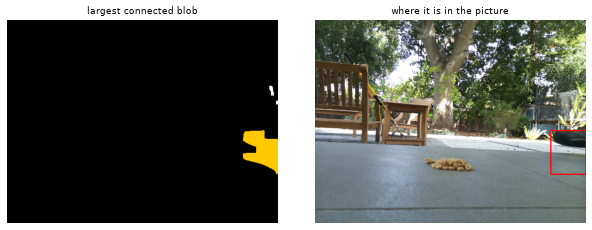

In [9]:
count, labels, stats, centroids = cv2.connectedComponentsWithStats(
    closed, connectivity=8)

blobs = sorted(
    ((int(stats[i, cv2.CC_STAT_AREA]),
      (int(stats[i, cv2.CC_STAT_LEFT]), int(stats[i, cv2.CC_STAT_TOP]),
       int(stats[i, cv2.CC_STAT_WIDTH]), int(stats[i, cv2.CC_STAT_HEIGHT])))
     for i in range(1, count)), reverse=True)

print(f"{count - 1} separate blobs; largest first:")
for area, box in blobs[:5]:
    print(f"  {area:7,} px  ({area / (W * H):6.2%} of frame)  box {box}")

area, (bx, by, bw, bh) = blobs[0]
painted = cv2.cvtColor(closed, cv2.COLOR_GRAY2BGR)
painted[labels == 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))] = (0, 200, 255)
overlay = cv2.resize(motion, (W, H)).copy()
cv2.rectangle(overlay, (bx, by), (bx + bw, by + bh), (0, 0, 255), 2)

show((painted, "largest connected blob"), (overlay, "where it is in the picture"))

## 8. Is it the right shape?

Blowing grass and swaying branches make thin, stringy, hollow blobs. Animals make
solid, compact ones. Two cheap numbers catch most of the difference:

- **extent** — blob area ÷ bounding-box area. A solid animal fills its box; a
  stringy branch does not.
- **aspect** — longest side ÷ shortest. Nothing with a backbone is eight times
  longer than it is wide.

The aspect test applies to every blob however large, because a grass stem stays a
grass stem at any size. The hollowness test is only used on small ones, since a
big animal half-hidden behind brush can genuinely come out sparse and we would
rather keep it.

In [10]:
def describe(area, box):
    x, y, w, h = box
    extent = area / max(w * h, 1)
    aspect = max(w, h) / max(min(w, h), 1)
    return extent, aspect

extent, aspect = describe(area, (bx, by, bw, bh))
print(f"largest blob: {area:,} px, {area / (W * H):.2%} of frame")
print(f"  extent {extent:.2f}  (needs >= {K['MIN_EXTENT']} when small)")
print(f"  aspect {aspect:.2f}  (needs <= {K['MAX_ASPECT']})")
print(f"  strong? {area >= K['STRONG_BLOB_AREA']}  "
      f"(>= {K['STRONG_BLOB_AREA']} px saves on sight)")

largest blob: 5,375 px, 1.75% of frame
  extent 0.63  (needs >= 0.3 when small)
  aspect 1.24  (needs <= 8.0)
  strong? True  (>= 1320 px saves on sight)


## 9. The whole checklist, on real frames

Here is the entire decision, applied to three real pictures: an empty patio, a
foot walking past, and the frame where a fern at the edge waves in the breeze.

In [11]:
def decide(path, background_f32):
    img = cv2.imread(str(path))
    small = cv2.resize(img, (W, H))
    plane = cv2.cvtColor(small, cv2.COLOR_BGR2YUV_I420)[:H]
    g = cv2.GaussianBlur(plane, (BK, BK), 0)
    bg = background_f32.astype("uint8")

    signed = g.astype(np.int16) - bg.astype(np.int16)
    shift, noise = float(np.median(signed)), float(np.median(np.abs(signed)))
    thr = min(K["MAX_PIXEL_THRESHOLD"],
              max(K["PIXEL_THRESHOLD"], int(K["NOISE_MULTIPLIER"] * noise + 5)))
    _, m = cv2.threshold(cv2.absdiff(g, bg), thr, 255, cv2.THRESH_BINARY)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, OPEN)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, CLOSE)
    changed = cv2.countNonZero(m) / (W * H)

    n, _, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    best = max(((int(st[i, cv2.CC_STAT_AREA]),
                 (int(st[i, cv2.CC_STAT_LEFT]), int(st[i, cv2.CC_STAT_TOP]),
                  int(st[i, cv2.CC_STAT_WIDTH]), int(st[i, cv2.CC_STAT_HEIGHT])))
                for i in range(1, n)), default=(0, (0, 0, 0, 0)))
    a, box = best
    ext, asp = describe(a, box) if a else (0.0, 0.0)
    frac = a / (W * H)
    luma = float(g.mean())

    strong = a >= K["STRONG_BLOB_AREA"]
    shaped = asp <= K["MAX_ASPECT"] and (strong or ext >= K["MIN_EXTENT"])

    if luma < K["MIN_MEAN_LUMA"]:                       rule, out = 1, "too dark"
    elif abs(shift) >= K["LIGHTING_SHIFT"]:             rule, out = 2, "lighting change"
    elif (changed >= K["BUSY_FRACTION"]
          and frac < K["DOMINANT_RATIO"] * changed):    rule, out = 3, "scene change"
    elif a == 0:                                        rule, out = 4, "nothing moved"
    elif not (a >= K["MIN_BLOB_AREA"] and shaped):      rule, out = 4, "too small / wrong shape"
    elif strong:                                        rule, out = 5, "STRONG MOTION - save"
    else:                                               rule, out = 6, "small - needs a second look"
    return dict(blob=a, frac=frac, extent=ext, aspect=asp, shift=shift,
                thr=thr, luma=luma, rule=rule, verdict=out, box=box, img=small)


print(f"{'frame':22} {'blob':>7} {'of frame':>9} {'ext':>5} {'asp':>5} "
      f"{'shift':>6} {'rule':>5}  verdict")
print("-" * 92)
results = {}
for name, bg in (("quiet_patio.jpg", bg_quiet),
                 ("motion_sandal.jpg", bg_motion),
                 ("falsepos_fern.jpg", bg_quiet)):
    r = decide(DATA / name, bg)
    results[name] = r
    print(f"{name:22} {r['blob']:7,} {r['frac']:9.2%} {r['extent']:5.2f} "
          f"{r['aspect']:5.2f} {r['shift']:+6.1f} {r['rule']:5}  {r['verdict']}")

frame                     blob  of frame   ext   asp  shift  rule  verdict
--------------------------------------------------------------------------------------------
quiet_patio.jpg              0     0.00%  0.00  0.00   +0.0     4  nothing moved
motion_sandal.jpg        5,375     1.75%  0.63  1.24   -2.0     5  STRONG MOTION - save
falsepos_fern.jpg          521     0.17%  0.53  2.45   +0.0     4  too small / wrong shape


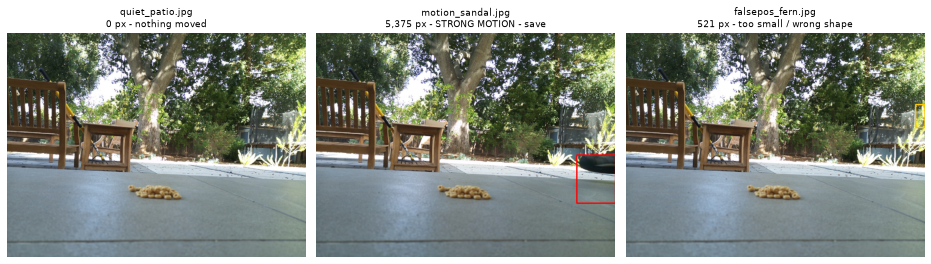

In [12]:
panes = []
for name, r in results.items():
    v = r["img"].copy()
    if r["blob"]:
        x, y, w_, h_ = r["box"]
        colour = (0, 0, 255) if "save" in r["verdict"] else (0, 200, 255)
        cv2.rectangle(v, (x, y), (x + w_, y + h_), colour, 2)
    panes.append((v, f"{name}\n{r['blob']:,} px - {r['verdict']}"))
show(*panes, height=3.8)

### Reading the table

The **sandal** is a big solid blob, far over the save-on-sight threshold: the
camera keeps it without hesitating. The **quiet patio** produces nothing at all.

The **fern** is the interesting one. It produces a blob of a few hundred pixels,
in the same place, hour after hour — and it lands just under the floor, so it is
rejected as too small. That floor was not guessed. It was measured: across an
afternoon the fern produced 19-95 pixels (at the old 320x240 size) while real
motion produced 8,960 and upwards. Two orders of magnitude apart, so the floor
sits between them, nearer the weeds than the wildlife.

The obvious alternative defence — *wait and see whether it is still there a
moment later* — does not work here, and the reason is worth remembering:

> A leaf that gusts and drops fails a second-sighting test, which is what that
> rule was built for. A frond in a **steady** breeze does not. It keeps moving,
> in one place, for hours, so it confirms itself perfectly.

The cost of the floor is honest and worth stating: it gives up on anything
smaller than about 150 pixels at 320x240, which at this lens is a squirrel
beyond ~10 m or a deer beyond ~40 m. A camera looking down a long trail needs
its own number, measured from its own site.

### A caveat this notebook cannot hide

Two seconds after the sandal, the camera took another photograph — and between
them the sun came out. Here is what our frozen background makes of it:

blob 3,424 px, signed shift +18.0 (limit 10) -> rule 2: lighting change


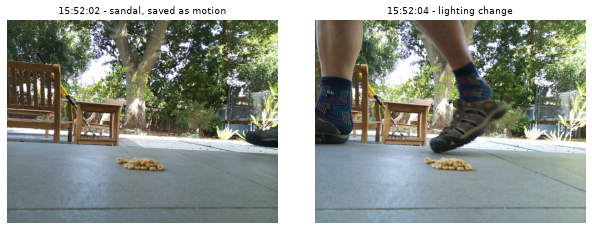

In [13]:
r = decide(DATA / "lighting_change.jpg", bg_motion)
print(f"blob {r['blob']:,} px, signed shift {r['shift']:+.1f} "
      f"(limit {K['LIGHTING_SHIFT']}) -> rule {r['rule']}: {r['verdict']}")

show((cv2.resize(cv2.imread(str(DATA / "motion_sandal.jpg")), (W, H)),
      "15:52:02 - sandal, saved as motion"),
     (r["img"], f"15:52:04 - {r['verdict']}"))

Rule 2 fires: more than half the frame moved the same way at once, so the
program calls it a change of light rather than a change of scene. And it is
right — the light *did* change.

The real camera saved this frame anyway, because its background had been
learning continuously through those two seconds and had already tracked most of
the drift. Ours has been frozen since 15:51. **That is a limitation of the
notebook, not of the program** — but it is a fair illustration of why the
two-speed learning in section 4 matters, and of why a background model is the
fiddliest part of the whole thing.

## 10. Where the AI camera comes in

The sensor runs a neural network on-chip, for free, on every frame. It knows 80
everyday objects — and not one of them is a deer, a raccoon or a fox.

So the program uses it in **one direction only**: the AI can turn a *maybe* into
a photograph, but it can never stop one. A "no" from a model that has never
heard of a raccoon means nothing at all.

There is one trap, which real data found for us. The AI recognises the furniture
too, every single frame, with a box covering a sixth of the scene — so a stray
27-pixel blob of noise landing inside the bench was "confirmed" by an object that
had not moved all day. A detection now has to be roughly the size of the thing
that moved before it counts as support.

In [14]:
for name in ("motion_sandal.jpg", "falsepos_fern.jpg"):
    info = index.get(name, {})
    print(f"{name}  (camera saved it as: {info.get('trigger', '?')})")
    for d in info.get("ai", []):
        print(f"    AI: {d['class']:12} {d['confidence']:.2f}")
    print()

motion_sandal.jpg  (camera saved it as: strong motion)
    AI: chair        0.56
    AI: bench        0.44

falsepos_fern.jpg  (camera saved it as: strong motion)
    AI: chair        0.56
    AI: bench        0.38
    AI: bench        0.38



## Future work

Everything above is deliberately simple arithmetic — subtract, threshold, count
connected pixels. That is a reasonable place for a camera that has to run all day
on a Raspberry Pi, and it is possible to understand every line of it. But it is
the bottom rung of a long ladder. Things worth trying next, roughly in order of
effort:

### Statistical background models (MOG2, KNN)
Instead of one average brightness per pixel, learn a *distribution* per pixel.
A patch of shimmering leaves naturally has a wide distribution and so demands a
bigger deviation before it counts as motion, which is exactly the fern problem.
Both ship with OpenCV as one-liners: `cv2.createBackgroundSubtractorMOG2()` and
`cv2.createBackgroundSubtractorKNN()`. In camera-trap comparisons KNN scores
slightly better on accuracy while MOG2 runs faster, which matters on a Pi.

*Worth knowing before trying:* on our own recorded frames MOG2 caught only 41% of
genuine motion against 100% for the current approach, so it is not a free
upgrade — it would need its history and learning rate tuned against our data.

### Colour, and the shadow problem
The one false positive we have deliberately given up on is a cloud shadow
crossing the patio. There is a standard answer: **a shadow keeps its colour and
changes only its brightness**, so comparing hue rather than brightness separates
shadow from object. MOG2's `detectShadows` does exactly this. The training
frames are now stored in YUV rather than greyscale specifically so this can be
tried on data we have already collected.

### Optical flow
Rather than asking *did this pixel change*, ask *where did it go*. Sparse flow
(Lucas–Kanade, `cv2.calcOpticalFlowPyrLK`) tracks corner features between frames;
dense flow (Farnebäck) gives a motion vector for every pixel. A fern oscillates
about a fixed point while an animal translates steadily across the frame, so
flow direction could separate the two cases that defeated our persistence rule.
Dense flow is probably too slow for a Pi at 4 Hz; sparse flow may not be.

### Three-frame differencing
Comparing frame *n* with both *n−1* and *n+1* and taking the intersection removes
the "ghost" a moving object leaves behind in simple differencing. Cheap, and a
natural next experiment after the current approach.

### Motion vectors from the video encoder
The Pi's hardware H.264 encoder already computes motion vectors for every
macroblock as a side effect of compression. Reading them costs essentially
nothing, and published work has used exactly this for video camera traps. This
may be the single best effort-to-reward option on this hardware.

### Learned detection on-device
The IMX500 can run a network we choose, not just the stock COCO one. A small
model trained on *our* frames — fern versus animal, on our patio, in our light —
would sidestep the hand-tuned thresholds entirely. This is what the training
bursts are being collected for.

### Techniques from the Wolfram Language
Mathematica has much of this built in and is a fast way to try an idea before
writing it in C-like OpenCV code:
`ImageDifference`, `MorphologicalComponents`, `ComponentMeasurements`,
`DeleteSmallComponents`, and `ImageFeatureTrack` for following points between
frames. See the companion notebook `step7_image_processing.nb`.

### And the thing no algorithm fixes
These cameras are **blind after dusk** — the AI Camera has no infra-red
illumination. Much of the wildlife worth photographing is nocturnal. No amount of
threshold tuning addresses that; it needs different hardware.

---

**Sources**

- [Motion vectors and deep neural networks for video camera traps](https://www.sciencedirect.com/science/article/pii/S1574954122001066)
- [Background subtraction to improve camera trap AI — WILDLABS](https://wildlabs.net/discussion/background-subtraction-improve-camera-trap-ai)
- [Optical Flow in OpenCV](https://learnopencv.com/optical-flow-in-opencv/)
- [OpenCV optical flow tutorial](https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_video/py_lucas_kanade/py_lucas_kanade.html)
- [Motion Detection: Frame Differencing](https://medium.com/@itberrios6/introduction-to-motion-detection-part-1-e031b0bb9bb2)
- [Wolfram Image Processing & Analysis](https://reference.wolfram.com/language/guide/ImageProcessing.html)
- [Wolfram Image Processing tutorial](https://reference.wolfram.com/language/tutorial/ImageProcessing.html)